# Figure 3

This figure shows pBOLD for data expected to be dominated by So fluctuations (e.g., cardiac-gated data with minimal pre-processing) and BOLD fluctuations (low motion, constant-gated, fully pre-processed data)

* We create a scatter plot comparing these two.
* We create a distribution of trigger delay times for two representative scans

In [1]:
import seaborn as sns
import pandas as pd
import panel as pn
import matplotlib.pyplot as plt
from utils.basics import get_dataset_index, DOWNLOAD_DIRS, ATLASES_DIR
import pickle
import os.path as osp

ATLAS_NAME = 'Power264-discovery'
ATLAS_DIR = osp.join(ATLASES_DIR,ATLAS_NAME)

import panel as pn
import holoviews as hv
import xarray as xr
from utils.fc_matrices import hvplot_fc
from utils.basics import get_altas_info

from utils.basics import CODE_DIR
pn.extension('mathjax')   # panel comms + latex support
hv.extension('bokeh')     # set backend early
from nilearn.connectome import sym_matrix_to_vec


/data/SFIMJGC_HCP7T/Apps/envs/generic_2025a/lib/python3.12/site-packages/nxviz/__init__.py:18: UserWarning: 
nxviz has a new API! Version 0.7.4 onwards, the old class-based API is being
deprecated in favour of a new API focused on advancing a grammar of network
graphics. If your plotting code depends on the old API, please consider
pinning nxviz at version 0.7.4, as the new API will break your old code.

To check out the new API, please head over to the docs at
https://ericmjl.github.io/nxviz/ to learn more. We hope you enjoy using it!

(This deprecation message will go away in version 1.0.)

  warnings.warn(


***
# 1. Load pBOLD estimates for the discovery dataset

In [2]:
DATASET='discovery'
CENSOR_MODE='ALL'
FC_METRIC='cov'

In [3]:
pBOLD_path = osp.join(CODE_DIR,'notebooks','summary_files',f'{DATASET}_pBOLD.nc')
print('++ pBOLD will be saved in %s' % pBOLD_path)

++ pBOLD will be saved in /data/SFIMJGC_HCP7T/BCBL2024/me_staticfc/code/notebooks/summary_files/discovery_pBOLD.nc


Load pBOLD for all scans in the discovery dataset, and select the scan-level estimate

In [4]:
pBOLD = xr.open_dataarray(pBOLD_path)
pBOLD = pBOLD.sel(fc_metric=FC_METRIC,ee_vs_ee='scan')
pBOLD = pBOLD.to_dataframe(name='pBOLD').reset_index().drop(['qc_metric','fc_metric','ee_vs_ee'],axis=1)
pBOLD.columns=['Subject','Session','Pre-processing','NORDIC','pBOLD']
pBOLD = pBOLD.set_index(['Subject','Session','Pre-processing','NORDIC'])
pBOLD.head(3)

pBOLD
Subject Session        Pre-processing   NORDIC          
MGSBJ01 constant_gated ALL_NoRegression off     0.647568
                                        on      0.648994
                       ALL_Basic        off     0.842564

***
# 2. Figure 3.a
Select the scans representing the two extreme signal regimes:

1) BOLD dominated: constant-gated data preprocessed with NORDIC and tedana
2) Non-BOLD dominated: cardiac-gated data with Basic pre-processing and no NORDIC

In [5]:
BOLD_heavy_data = pBOLD.loc[:,'constant_gated','ALL_Tedana-fastica','on']
So_heavy_data   = pBOLD.loc[:,'cardiac_gated','ALL_Basic','off']
df = pd.concat([BOLD_heavy_data,So_heavy_data],axis=1)
df.columns=['BOLD Dominated','So Dominated']

In [6]:
pn.Row(pn.Column(pn.pane.Markdown('### Cardiac Gated'),So_heavy_data.sort_values(by='pBOLD')),
       pn.Column(pn.pane.Markdown('### Constant Gated'),BOLD_heavy_data.sort_values(by='pBOLD')))

BokehModel(combine_events=True, render_bundle={'docs_json': {'698baa89-c284-478a-8219-deff99d86a41': {'version…

Generate panel a: bar plot with pBOLD values for these two scenario

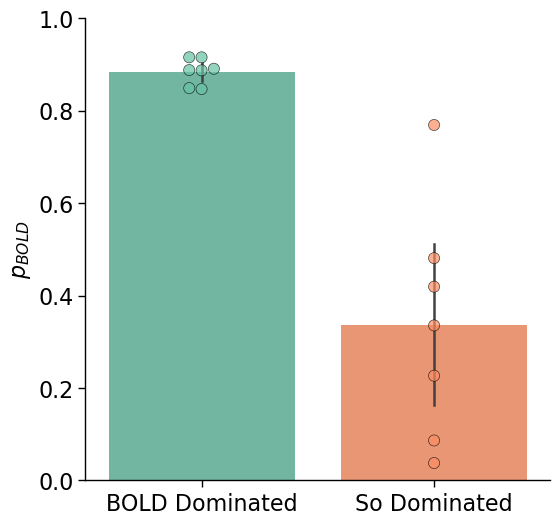

In [7]:
sns.set_context("paper", rc={"xtick.labelsize": 16, "ytick.labelsize": 16, "axes.labelsize": 16, 'legend.fontsize':16})
fig, axs = plt.subplots(1,1,figsize=(6,6));
sns.despine(top=True, right=True)
sns.set_palette('Set2')
f = sns.barplot(data=df)
sns.swarmplot(data=df, edgecolor="black", linewidth=0.5, alpha=0.7,s=8)
sns.despine()
f.set_ylim(0,1)
f.grid(False)
f.set_ylabel('$p_{BOLD}$');

***
# 3. Figure 3.b

Load FC matrices for all scans in the discovery dataset

In [8]:
fc_path = osp.join(CODE_DIR,'notebooks','summary_files',f'{DATASET}_FC.pkl')
print('++ FC will be saved in %s' % fc_path)
with open(fc_path, 'rb') as f:
    fc = pickle.load(f)

++ FC will be saved in /data/SFIMJGC_HCP7T/BCBL2024/me_staticfc/code/notebooks/summary_files/discovery_FC.pkl


Load ROI info

In [9]:
roi_info_df, power264_nw_cmap = get_altas_info(ATLAS_DIR,ATLAS_NAME)
roi_idxs = roi_info_df.set_index(['ROI_Name', 'ROI_ID', 'Hemisphere', 'Network']).index

++ INFO [get_nw_cmap]: Gathering ROI information from file /data/SFIMJGC_HCP7T/BCBL2024/atlases/Power264-discovery/Power264-discovery.roi_info.csv
++ INFO: Number of ROIs = 226 | Number of Connections = 25425


In [10]:
cg_highest_pBOLD_sbj = BOLD_heavy_data.sort_values(by='pBOLD',ascending=False).index[0]
cg_lowest_pBOLD_sbj  = BOLD_heavy_data.sort_values(by='pBOLD',ascending=True).index[0]
print('++ Constant-gated scan with the highest pBOLD is for Subject=%s' % cg_highest_pBOLD_sbj)
print('++ Constant-gated scan with the lowest  pBOLD is for Subject=%s' % cg_lowest_pBOLD_sbj)

++ Constant-gated scan with the highest pBOLD is for Subject=MGSBJ06
++ Constant-gated scan with the lowest  pBOLD is for Subject=MGSBJ05


In [11]:
left_fc = fc[(cg_highest_pBOLD_sbj,'constant_gated','ALL_Tedana-fastica','on','e02|e02','R')]
right_fc = fc[(cg_lowest_pBOLD_sbj,'constant_gated','ALL_Tedana-fastica','on','e02|e02','R')]

In [12]:
left_label = hv.Text(x=50,y=210, text=r'pBOLD=%.2f' % BOLD_heavy_data.loc[cg_highest_pBOLD_sbj].values[0], fontsize=20).opts(text_font_style='italic')
right_label = hv.Text(x=50,y=210, text=r'pBOLD=%.2f' % BOLD_heavy_data.loc[cg_lowest_pBOLD_sbj].values[0], fontsize=20).opts(text_font_style='italic')

In [13]:
plot_fc_left   = hvplot_fc(left_fc,major_label_overrides='regular_grid', net_cmap=power264_nw_cmap,
         cmap='RdBu_r', by='Network', add_labels=False, colorbar_position='left',clim=(-.8,.8),
         cbar_title=r"$$FC_{R}(TE2,TE2)$$", cbar_title_fontsize=14, ticks_font_size=14).opts(tools=[], active_tools=[],toolbar=None)
plot_fc_right   = hvplot_fc(right_fc,major_label_overrides='regular_grid', net_cmap=power264_nw_cmap,
         cmap='RdBu_r', by='Network', add_labels=False, colorbar_position='left',clim=(-.8,.8),
         cbar_title=r"$$FC_{R}(TE2,TE2)$$", cbar_title_fontsize=14, ticks_font_size=14).opts(tools=[],active_tools=[], toolbar=None)
pn.Row((plot_fc_left*left_label).opts(toolbar=None),
        (plot_fc_right * right_label).opts(toolbar=None)).save('./figures/pBOLD_Figure03_b.html')

Here is Panel b in static form (for github rendering purposes)

![Figure 3.b](figures/pBOLD_Figure03_b.png)

***
# 4. Figure 3.c

In [14]:
cg_highest_pBOLD_sbj = So_heavy_data.sort_values(by='pBOLD',ascending=False).index[0]
cg_lowest_pBOLD_sbj  = So_heavy_data.sort_values(by='pBOLD',ascending=True).index[0]
print('++ Cardiac-gated scan with the highest pBOLD is for Subject=%s' % cg_highest_pBOLD_sbj)
print('++ Cardiac-gated scan with the lowest  pBOLD is for Subject=%s' % cg_lowest_pBOLD_sbj)

++ Cardiac-gated scan with the highest pBOLD is for Subject=MGSBJ02
++ Cardiac-gated scan with the lowest  pBOLD is for Subject=MGSBJ05


In [15]:
left_fc = fc[(cg_lowest_pBOLD_sbj,'cardiac_gated','ALL_Basic','off','e02|e02','R')]
right_fc = fc[(cg_highest_pBOLD_sbj,'cardiac_gated','ALL_Basic','off','e02|e02','R')]

In [ ]:
left_label = hv.Text(x=50,y=210, text='pBOLD=%.2f' % So_heavy_data.loc[cg_lowest_pBOLD_sbj].values[0], fontsize=20).opts(text_font_style='italic', text_color='w')
right_label = hv.Text(x=50,y=210, text='pBOLD=%.2f' % So_heavy_data.loc[cg_highest_pBOLD_sbj].values[0], fontsize=20).opts(text_font_style='italic')

In [17]:
plot_fc_left   = hvplot_fc(left_fc,major_label_overrides='regular_grid', net_cmap=power264_nw_cmap,
         cmap='RdBu_r', by='Network', add_labels=False, colorbar_position='left',clim=(-.8,.8),
         cbar_title=r"$$FC_{R}(TE2,TE2)$$", cbar_title_fontsize=14, ticks_font_size=14).opts(tools=[], active_tools=[],toolbar=None)
plot_fc_right   = hvplot_fc(right_fc,major_label_overrides='regular_grid', net_cmap=power264_nw_cmap,
         cmap='RdBu_r', by='Network', add_labels=False, colorbar_position='left',clim=(-.8,.8),
         cbar_title=r"$$FC_{R}(TE2,TE2)$$", cbar_title_fontsize=14, ticks_font_size=14).opts(tools=[],active_tools=[], toolbar=None)
pn.Row((plot_fc_left*left_label).opts(toolbar=None),
        (plot_fc_right * right_label).opts(toolbar=None)).save('./figures/pBOLD_Figure03_c.html')

Here is panel c in static form (for github rendering)

![Figure 3.c](figures/pBOLD_Figure03_c.png)

***
# 5. Figure 3.d

In [26]:
from utils.dashboard import gen_scatter

In [27]:
cg_highest_pBOLD_sbj = BOLD_heavy_data.sort_values(by='pBOLD',ascending=False).index[0]
cg_lowest_pBOLD_sbj  = BOLD_heavy_data.sort_values(by='pBOLD',ascending=True).index[0]
print('++ Constant-gated scan with the highest pBOLD is for Subject=%s' % cg_highest_pBOLD_sbj)
print('++ Constant-gated scan with the lowest  pBOLD is for Subject=%s' % cg_lowest_pBOLD_sbj)

++ Constant-gated scan with the highest pBOLD is for Subject=MGSBJ06
++ Constant-gated scan with the lowest  pBOLD is for Subject=MGSBJ05


In [36]:
left_scatter = gen_scatter(DATASET,fc,cg_highest_pBOLD_sbj,'constant_gated','ALL_Tedana-fastica','on','e01|e01','e03|e03','C', show_linear_fit=False, ax_lim=1, hexbin=False, title=None).opts(fontscale=1.5, toolbar=None)
right_scatter = gen_scatter(DATASET,fc,cg_lowest_pBOLD_sbj,'constant_gated','ALL_Tedana-fastica','on','e01|e01','e03|e03','C', show_linear_fit=False, ax_lim=1, hexbin=False, title=None).opts(fontscale=1.5, toolbar=None)
pn.Row(left_scatter,right_scatter).save('./figures/pBOLD_Figure03_d.html')

Static version of Figure 3.d (for github)

![Figure 3.d](figures/pBOLD_Figure03_d.png)

***
# 6. Figure 3.e

In [37]:
cg_highest_pBOLD_sbj = So_heavy_data.sort_values(by='pBOLD',ascending=False).index[0]
cg_lowest_pBOLD_sbj  = So_heavy_data.sort_values(by='pBOLD',ascending=True).index[0]
print('++ Cardiac-gated scan with the highest pBOLD is for Subject=%s' % cg_highest_pBOLD_sbj)
print('++ Cardiac-gated scan with the lowest  pBOLD is for Subject=%s' % cg_lowest_pBOLD_sbj)

++ Cardiac-gated scan with the highest pBOLD is for Subject=MGSBJ02
++ Cardiac-gated scan with the lowest  pBOLD is for Subject=MGSBJ05


In [39]:
left_scatter = gen_scatter(DATASET,fc,cg_lowest_pBOLD_sbj,'cardiac_gated','ALL_Basic','off','e01|e01','e03|e03','C', show_linear_fit=False, ax_lim=1, hexbin=False, title=None).opts(fontscale=1.5, toolbar=None)
right_scatter = gen_scatter(DATASET,fc,cg_highest_pBOLD_sbj,'cardiac_gated','ALL_Basic','off','e01|e01','e03|e03','C', show_linear_fit=False, ax_lim=1, hexbin=False, title=None).opts(fontscale=1.5, toolbar=None)
pn.Row(left_scatter,right_scatter).save('./figures/pBOLD_Figure03_e.html')

Static version of Figure 3.e (for github)

![Figure 3.e](figures/pBOLD_Figure03_e.png)

***
# 7. Figure 3.f

Identify the cardiac-gated scans with the highest and lowest pBOLD values

In [18]:
cg_highest_pBOLD_sbj = So_heavy_data.sort_values(by='pBOLD',ascending=False).index[0]
cg_lowest_pBOLD_sbj  = So_heavy_data.sort_values(by='pBOLD',ascending=True).index[0]
print('++ Cardiac-gated scan with the highest pBOLD is for Subject=%s' % cg_highest_pBOLD_sbj)
print('++ Cardiac-gated scan with the lowest  pBOLD is for Subject=%s' % cg_lowest_pBOLD_sbj)

++ Cardiac-gated scan with the highest pBOLD is for Subject=MGSBJ02
++ Cardiac-gated scan with the lowest  pBOLD is for Subject=MGSBJ05


Load Trigger info for the highest pBOLD scan

In [19]:
path = osp.join(DOWNLOAD_DIRS[DATASET],cg_highest_pBOLD_sbj,'cardiac_gated','func',f'{cg_highest_pBOLD_sbj}_cardiac_gated_task-rest.Triggers.1D')
trigger_df = pd.read_csv(path, sep=' ', skiprows=2, header=None)
trigger_df.columns = ['onset','slice','acquisition']
highest_pBOLD_tigger_onsets = trigger_df.set_index(['slice','acquisition']).loc[0,:].diff() - 2500

Load Trigger information for the lowest pBOLD scan

In [20]:
# Load Trigger info for cardiac gated scan with lowest pBOLD
path = osp.join(DOWNLOAD_DIRS[DATASET],cg_lowest_pBOLD_sbj,'cardiac_gated','func',f'{cg_lowest_pBOLD_sbj}_cardiac_gated_task-rest.Triggers.1D')
trigger_df = pd.read_csv(path, sep=' ', skiprows=2, header=None)
trigger_df.columns = ['onset','slice','acquisition']
lowest_pBOLD_tigger_onsets = trigger_df.set_index(['slice','acquisition']).loc[0,:].diff() - 2500

In [23]:
df = pd.concat([lowest_pBOLD_tigger_onsets,highest_pBOLD_tigger_onsets,],axis=1).dropna()
df.columns = ['pBOLD=%.2f' % So_heavy_data.loc[cg_lowest_pBOLD_sbj].values[0],'pBOLD=%.2f' % So_heavy_data.loc[cg_highest_pBOLD_sbj].values[0]]

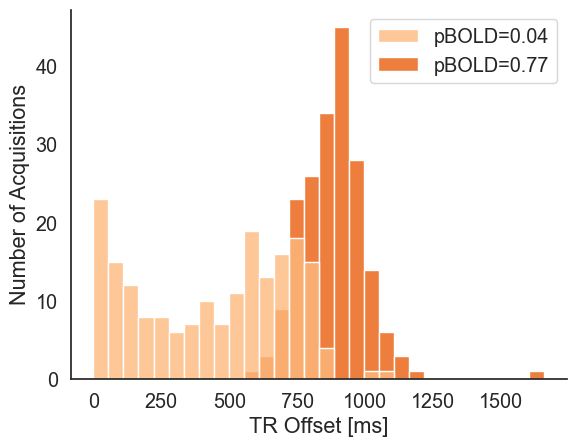

In [24]:
sns.set(font_scale=1.3)
sns.set_style('white')
f = sns.histplot(data=df, palette='Oranges', bins=30, alpha=.8)
f.set_xlabel('TR Offset [ms]')
f.set_ylabel('Number of Acquisitions')
sns.despine()